## `1.` AES S-BOX and Hamming Weight Calculation

In [ ]:
import numpy as np


# AES S-Box in the form of a matrix 'SBOX'
SBOX = np.array([
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16,
], dtype=np.uint8)


# Hamming Weight
HW_TABLE = np.array([bin(x).count("1") for x in range(256)], dtype=np.uint8)


## `2.` Setting up Google Drive Connection and Loading the Data

In [ ]:
import csv
import time
import os
import matplotlib.pyplot as plt

from google.colab import drive


if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
    print("Drive mounted successfully")
else:
    print("Drive already mounted")



# Expected base directory (change if needed)
base_dir = "/content/drive/My Drive/Colab Notebooks/SC4015"

# Expected file
waveform_filen = os.path.join(base_dir, "waveform.csv")
results_dir = os.path.join(base_dir, "results")

print("Checking Environment Setup....\n")

# 1. Check if base directory exists
if not os.path.exists(base_dir):
    raise FileNotFoundError(
        f"Base directory not found:\n{base_dir}\n\n"
        "Make sure you have mounted Google Drive and the path is correct."
    )

print(f"Found base directory: {base_dir}")

# 2. Check if waveform.csv exists
if not os.path.exists(waveform_filen):
    raise FileNotFoundError(
        f"'waveform.csv' not found at:\n{waveform_filen}\n\n"
        "Please upload the file or update the path."
    )

print(f"Found waveform file: {waveform_filen}")

if not os.path.exists(results_dir):
    os.makedirs(results_dir)
    print(f"Created output directory: {results_dir}")
else:
    print(f"Output directory already exists: {results_dir}")


def load_data(path):
    with open(path, 'r') as f:
        reader = csv.reader(f)
        data = list(reader)

    pts = np.array([[int(row[0][i:i+2], 16) for i in range(0, 32, 2)] for row in data], dtype=np.uint8)   # extract plaintext

    cts_hex = [row[1] for row in data]   # extract ciphertext

    tr = np.array([row[2:-1] for row in data], dtype=np.float32)    # extract power trace values from column 2 until second last column

    return pts, cts_hex, tr


if 'traces' not in globals() or 'pt_matrix' not in globals() or 'ct_list' not in globals():
    print("Reading CSV from Drive...")
    pt_matrix, ct_list, traces = load_data(waveform_filen)
    print(f"Success: Loaded {traces.shape[0]} traces.")
else:
    print("Data already in memory. Skipping read.")



Mounted at /content/drive
Drive mounted successfully
Checking Environment Setup....

Found base directory: /content/drive/My Drive/Colab Notebooks/SC4015
Found waveform file: /content/drive/My Drive/Colab Notebooks/SC4015/waveform.csv
Output directory already exists: /content/drive/My Drive/Colab Notebooks/SC4015/results
Reading CSV from Drive... this may take a moment.
Success: Loaded 110 traces.


## `3.` Correlation Power Analysis (CPA)


Output directory already exists: /content/drive/My Drive/Colab Notebooks/SC4015/results/plots

===== BYTE 0 follows =====



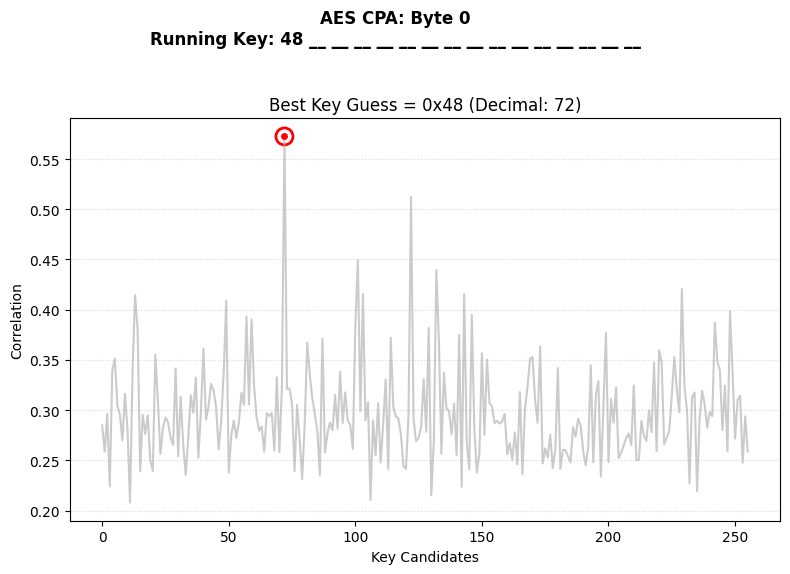


===== BYTE 1 follows =====



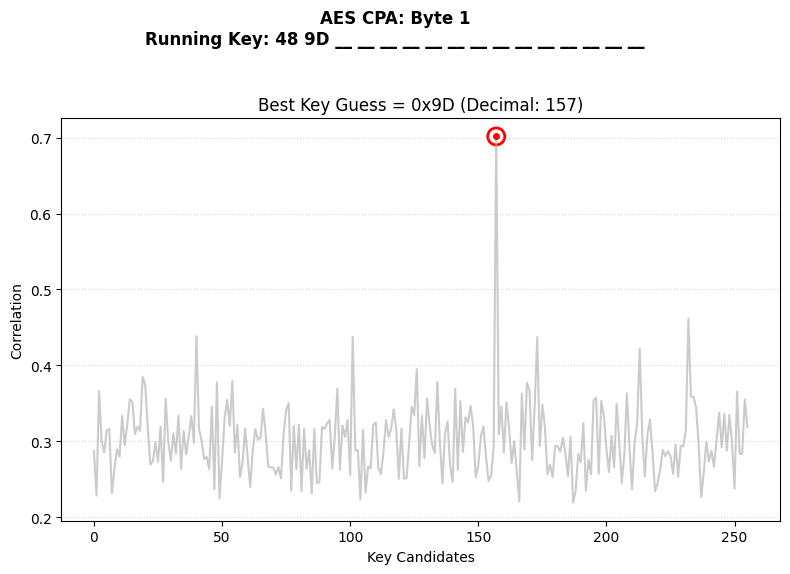


===== BYTE 2 follows =====



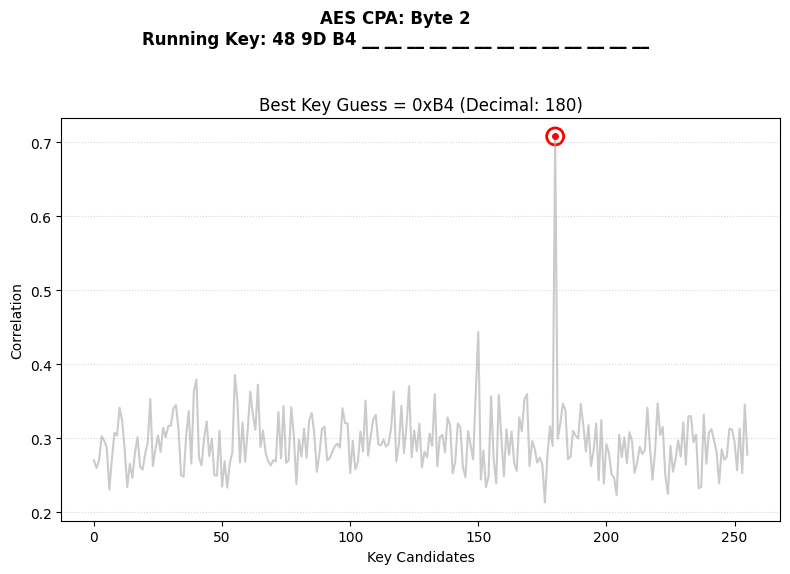


===== BYTE 3 follows =====



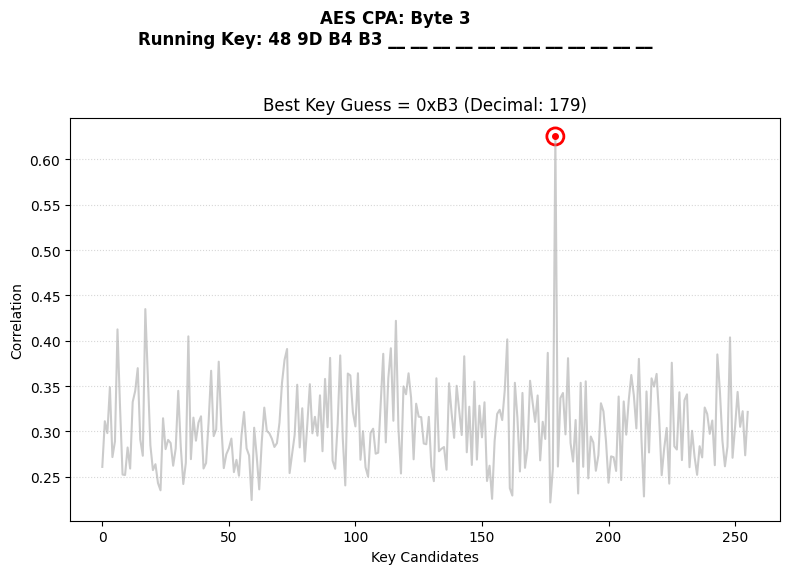


===== BYTE 4 follows =====



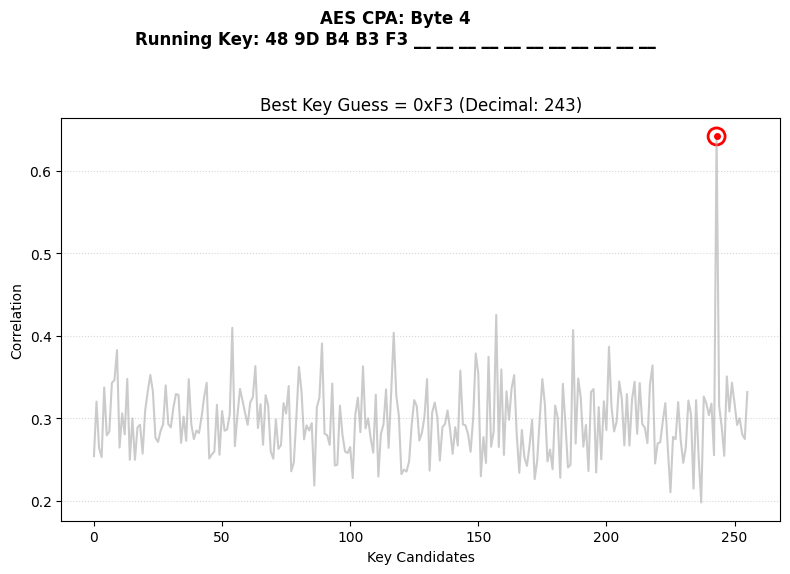


===== BYTE 5 follows =====



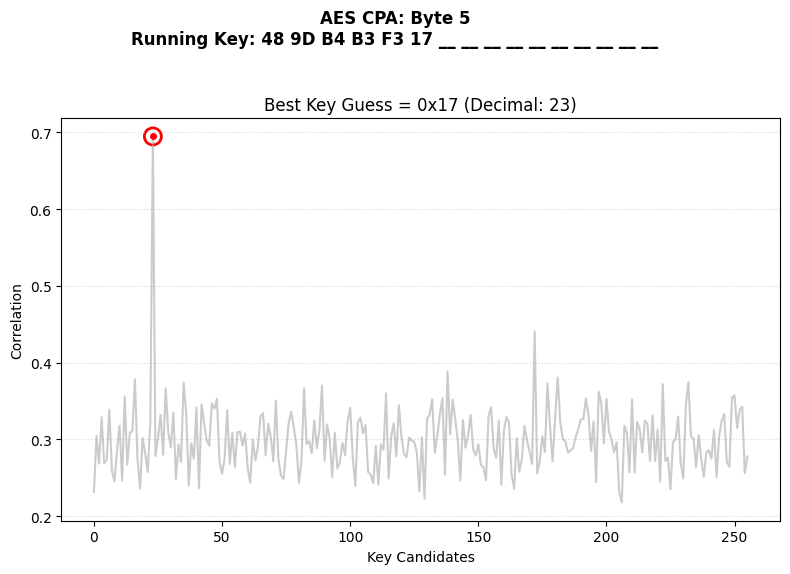


===== BYTE 6 follows =====



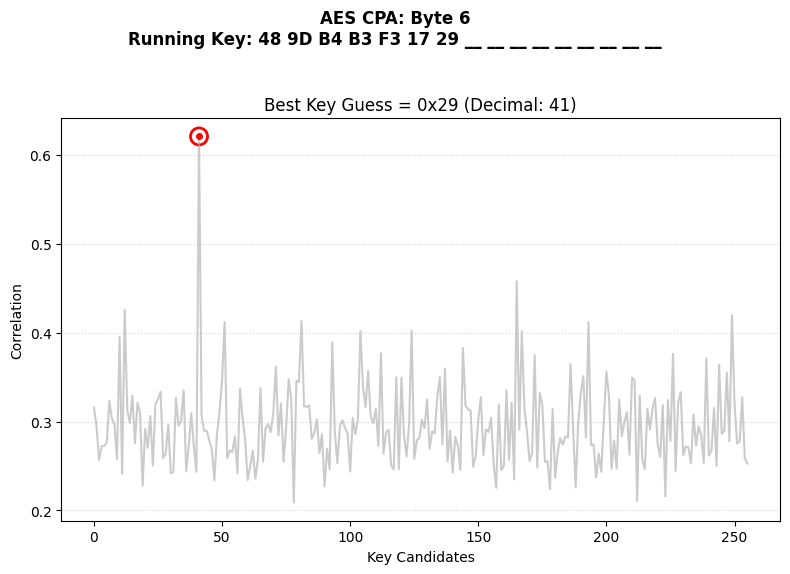


===== BYTE 7 follows =====



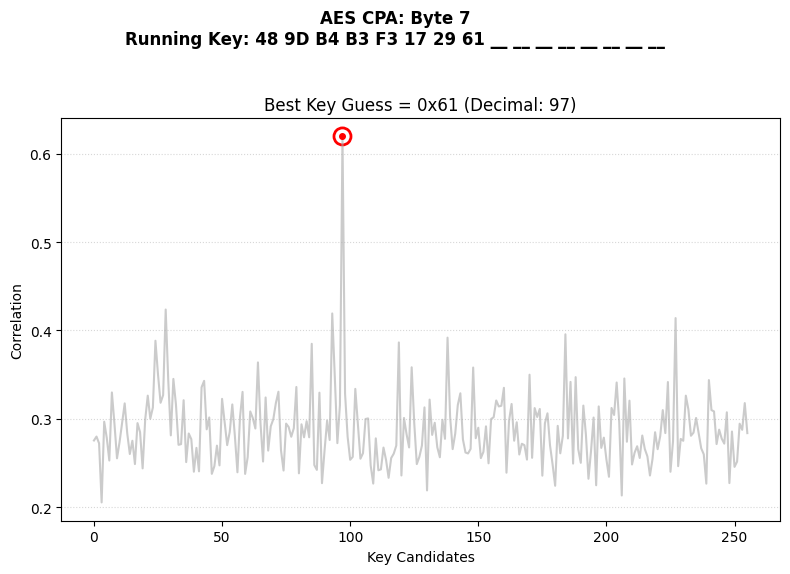


===== BYTE 8 follows =====



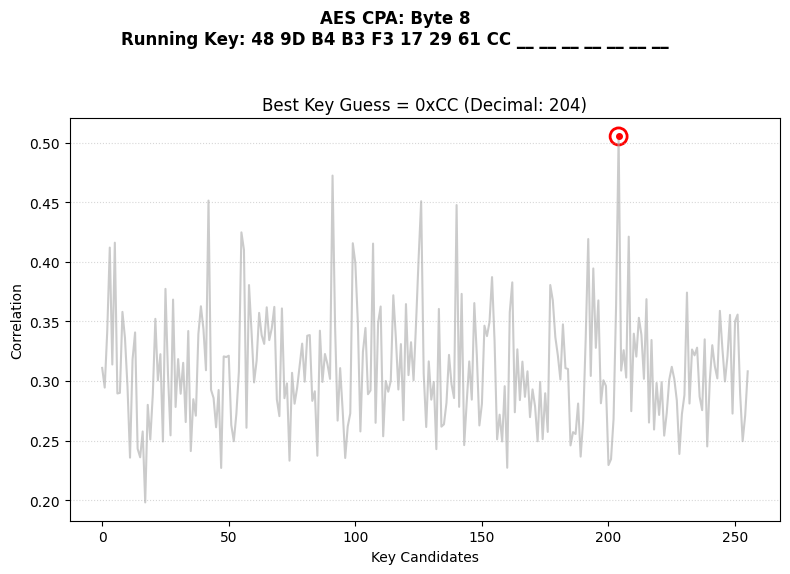


===== BYTE 9 follows =====



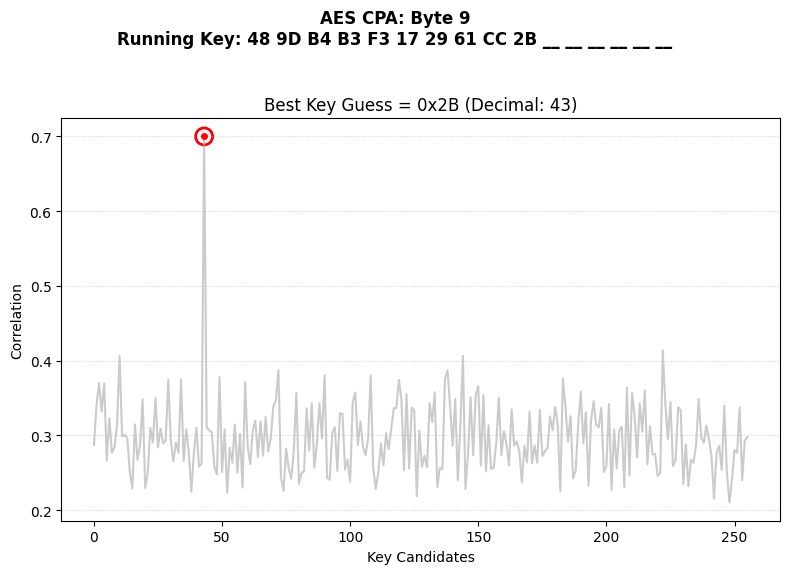


===== BYTE 10 follows =====



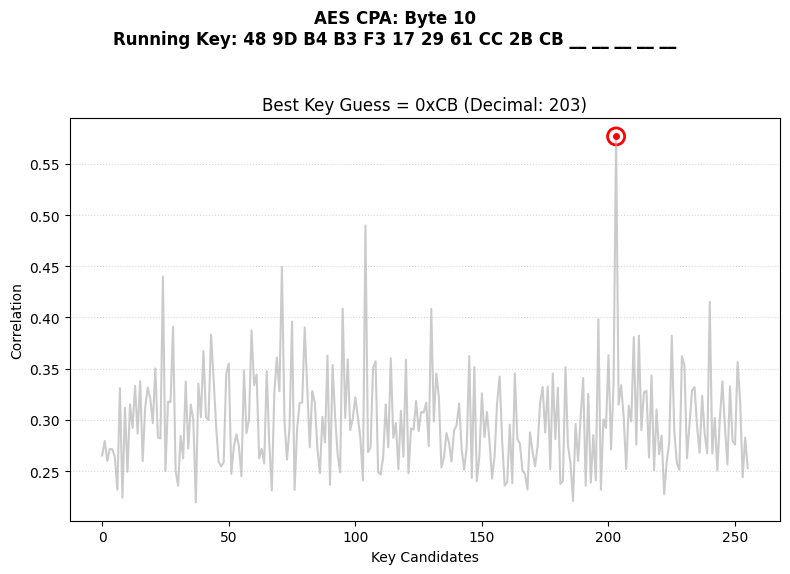


===== BYTE 11 follows =====



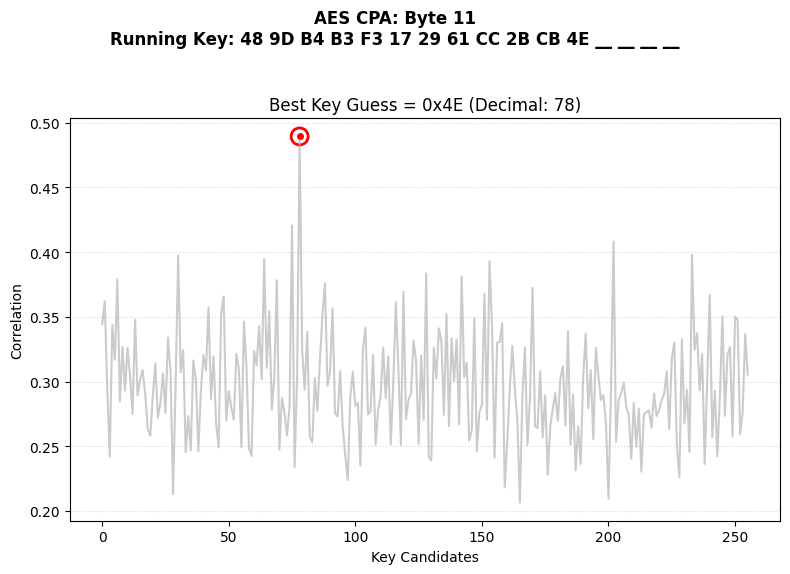


===== BYTE 12 follows =====



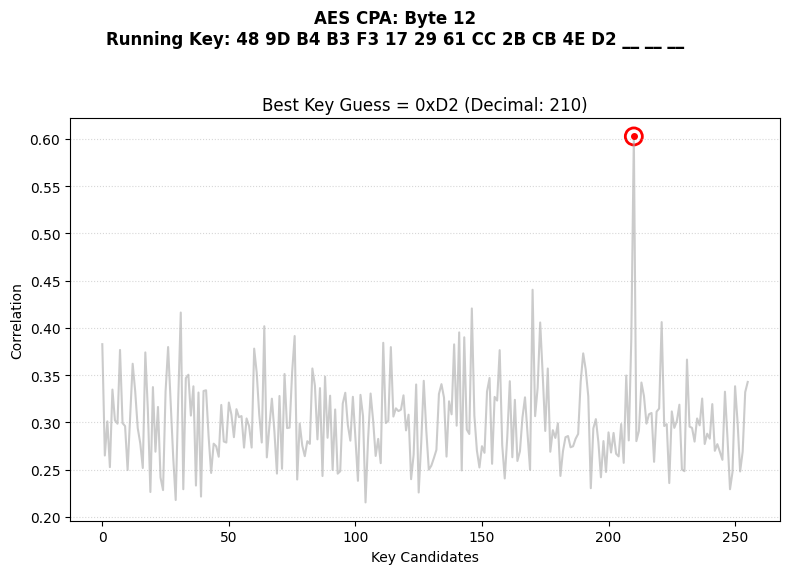


===== BYTE 13 follows =====



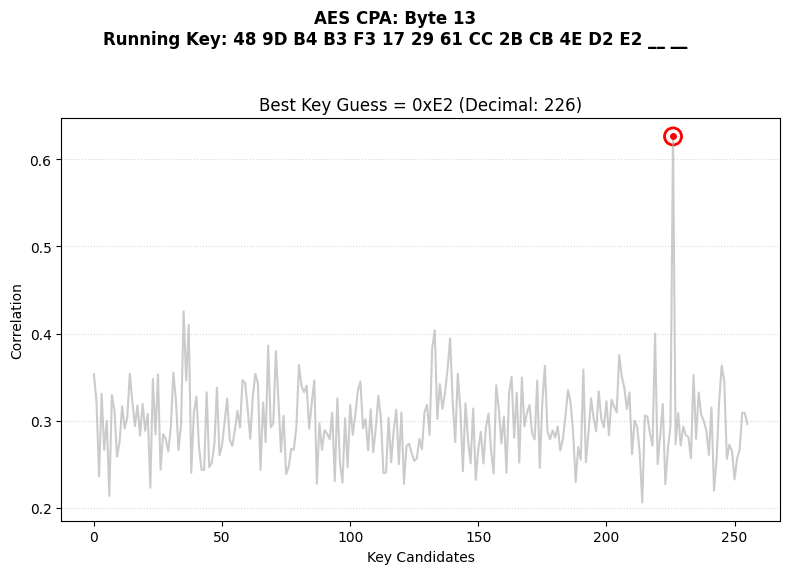


===== BYTE 14 follows =====



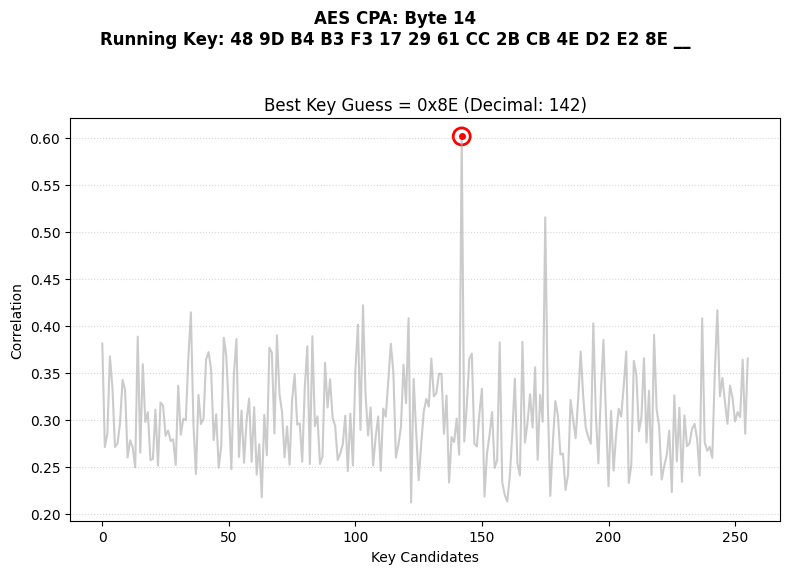


===== BYTE 15 follows =====



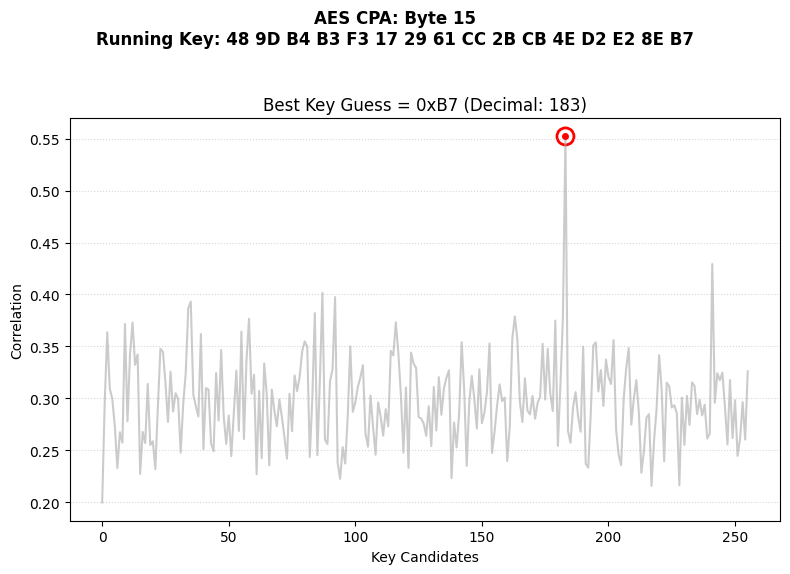


RECOVERED KEY:  48 9D B4 B3 F3 17 29 61 CC 2B CB 4E D2 E2 8E B7


In [ ]:
plot_dir = os.path.join(results_dir, "plots")
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)
    print(f"Created output directory: {plot_dir}")
else:
    print(f"Output directory already exists: {plot_dir}")


recovered_key = []
key_strengths = [] # To store the max correlation value for each byte
show_second_plot = False


for b in range(16):
    n_traces = traces.shape[0]
    hyp_hw = np.zeros((256, n_traces))
    for k in range(256):
        hyp_hw[k, :] = HW_TABLE[SBOX[pt_matrix[:, b] ^ k]]

    model_c = hyp_hw - hyp_hw.mean(axis=1, keepdims=True)
    trace_c = traces - traces.mean(axis=0, keepdims=True)

    num = np.dot(model_c, trace_c)
    den = np.sqrt(np.sum(model_c**2, axis=1, keepdims=True)) * np.sqrt(np.sum(trace_c**2, axis=0, keepdims=True))

    corr = np.abs(num / (den + 1e-10))    # corr is the 2D matrix => 256 key candidates * time samples

    max_corrs = np.max(corr, axis=1)
    best_guess = np.argmax(max_corrs)

    recovered_key.append(best_guess)
    key_strengths.append(max_corrs[best_guess])

    running_key_spaced = " ".join(f"{k:02X}" for k in recovered_key)
    remaining_spaced = " __" * (16 - len(recovered_key))

    running_key_display = running_key_spaced + remaining_spaced


    if (show_second_plot == True ):
      fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    else:
      fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))


    best_guess_hex = hex(best_guess).upper().replace('X', 'x')

    #fig.suptitle(f"AES Analysis: Byte {b}", fontsize=14, fontweight='bold')
    fig.suptitle(
    f"AES CPA: Byte {b}\nRunning Key: {running_key_display}",
    fontsize=12,
    fontweight='bold'
    )
    ax1.plot(max_corrs, color='darkgray', alpha=0.6)


    ax1.plot(best_guess, max_corrs[best_guess], 'ro', markersize=4)
    ax1.scatter(best_guess, max_corrs[best_guess],
                facecolors='none', edgecolors='red',
                s=150, linewidths=2)

    ax1.set_title(f"Best Key Guess = {best_guess_hex} (Decimal: {best_guess})")

    ax1.set_xlabel("Key Candidates")
    ax1.set_ylabel("Correlation")
    ax1.grid(True, axis='y', linestyle=':', alpha=0.5)

    ax1.set_title(f"Best Key Guess = {best_guess_hex} (Decimal: {best_guess})")

    ax1.set_xlabel("Key Candidates")
    ax1.set_ylabel("Correlation")
    ax1.grid(True, axis='y', linestyle=':', alpha=0.5)


    # --- Graph 2: Correlation Spike in Time Domain ---
    if ( show_second_plot == True ):
      ax2.plot(corr[best_guess], color='tab:blue', linewidth=1)
      ax2.set_xlabel("Time Sample (Index)")
      ax2.set_ylabel("Correlation Value")
      ax2.set_title(f"Temporal Leakage Point for {best_guess_hex}")
      ax2.grid(True, linestyle=':', alpha=0.5)


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"{plot_dir}/byte_{b:02d}_analysis.png", dpi=150)
    print(f"\n===== BYTE {b} follows =====\n")
    plt.show()
    plt.close(fig)


# Final Output (Secret Key)
final_key_hex = "".join([f"{k:02x}" for k in recovered_key])
print("\nRECOVERED KEY: " + " " + " ".join(f"{k:02X}" for k in recovered_key))


import pandas as pd
summary_df = pd.DataFrame({
    'Byte': range(16),
    'Key_Hex': [hex(k) for k in recovered_key],
    'Max_Correlation': key_strengths
})
summary_df.to_csv(f"{results_dir}/analysis_summary.csv", index=False)



## `4.` Check if package for verification exists

In [ ]:
try:
    from Crypto.Cipher import AES
    print("pycryptodome already installed")
except ImportError:
    print("Installing pycryptodome...")
    !pip install pycryptodome

Installing pycryptodome...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 41.0 MB/s eta 0:00:00


## `5.` Verifying if Recovered Key is accurate

In [ ]:
from Crypto.Cipher import AES

key_bytes = bytes(recovered_key)

original_pt_hex = "".join(f"{b:02x}" for b in pt_matrix[0]).upper()
sample_ct_hex = ct_list[0].upper()

cipher = AES.new(key_bytes, AES.MODE_ECB)
rep_ct = 55

try:
    decrypted_bytes = cipher.decrypt(bytes.fromhex(sample_ct_hex))
    decrypted_hex = decrypted_bytes.hex().upper()

    print("=" * rep_ct)
    print("               VERIFICATION       ")
    print("=" * rep_ct)
    print(f"Target Ciphertext : {sample_ct_hex}")
    print(f"Decrypted Result  : {decrypted_hex}")
    print(f"Original Plaintext: {original_pt_hex}")
    print("-" * rep_ct)

    if decrypted_hex == original_pt_hex:
        print("SUCCESS: The recovered key decrypts the ciphertext.")
        print("\nRecovered (Secret) Key (Hex):")
        print(" ".join(f"{k:02X}" for k in recovered_key))
    else:
        print("FAILURE: Decryption mismatch.")
        print("Possible causes: incorrect key byte(s), wrong byte order, or mismatched plaintext/ciphertext pair.")
    print("=" * rep_ct)

except Exception as e:
    print(f"An error has occurred: {e}")

               VERIFICATION       
Target Ciphertext : 6C4A1DE1148387B5645308323C59B7D6
Decrypted Result  : F22E10CA18045B15EC056215AF1E2FEE
Original Plaintext: F22E10CA18045B15EC056215AF1E2FEE
-------------------------------------------------------
SUCCESS: The recovered key decrypts the ciphertext.

Recovered (Secret) Key (Hex):
48 9D B4 B3 F3 17 29 61 CC 2B CB 4E D2 E2 8E B7
